# Insurance Pricing — Model Validation (Ordered Lorenz Curve)

This notebook validates the frequency and severity models trained in notebooks
`01` and `02` using the **Ordered Lorenz Curve** — the standard actuarial
metric for assessing a pricing model's **discrimination power**.

## What is the Ordered Lorenz Curve?

Given:
- `S(x)` = predicted risk for policy `x` (e.g., predicted pure premium)
- `L(x)` = actual losses for policy `x`
- `E(x)` = exposure for policy `x`

The Ordered Lorenz Curve is constructed by:
1. Sorting policies by `S(x)` in ascending order
2. Computing cumulative normalised exposure `CE(x)` and cumulative normalised losses `CL(x)`
3. Plotting `(CE(x), CL(x))`

A **perfect model** concentrates all losses in the highest-risk segment:
the curve bows sharply away from the diagonal.

The **Gini coefficient** measures the area between the Lorenz curve and
the 45° equality line, normalised by the maximum achievable area (the
perfect model's Gini). It ranges from 0 (no discrimination) to 1 (perfect).

## Comparison Lorenz Curve

To compare model A vs model B (where B is a baseline):
1. Rank policies by the **ratio** `S_A(x) / S_B(x)` (relative risk)
2. X-axis: cumulative normalised `S_B(x)` (as if B priced perfectly)
3. Y-axis: cumulative normalised `L(x)`

If A is better than B, the curve bows away from the diagonal, and the
Gini is positive. If A == B, the curve is the diagonal (Gini = 0).

> **Prerequisite:** Run `02_severity_model.ipynb` first to generate `data/all_predictions.csv`.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

## 01. Ordered Lorenz Functions

In [2]:
def _perfect_gini(target: np.ndarray, weight: np.ndarray, ascending: bool) -> float:
    """Gini of the perfect model (target ranked against itself)."""
    order = np.argsort(target) if ascending else np.argsort(target)[::-1]
    t = target[order] / target.sum()
    w = weight[order] / weight.sum()
    cumul_t = np.cumsum(t)
    cumul_w = np.cumsum(w)
    lift = (cumul_w - cumul_t) * w
    return 2 * lift.sum() if ascending else -2 * lift.sum()

In [3]:
def ordered_lorenz(
    data: pd.DataFrame,
    target: str,
    ranking: str = None,
    weight: str = None,
    ascending: bool = True,
    ax=None,
) -> float:
    """
    Plot an Ordered Lorenz curve and return the normalised Gini coefficient.

    Parameters
    ----------
    data     : pd.DataFrame
    target   : str  — column with actual losses (e.g., 'claim_amount', 'n_claims')
    ranking  : str  — column used to rank policies (e.g., model predictions).
                      Defaults to target (perfect model baseline).
    weight   : str  — column with exposure or n_claims for normalisation.
                      If None, all policies receive equal weight.
    ascending: bool — True = Lorenz curve below diagonal (standard orientation)
    ax       : matplotlib Axes — if None, no plot is produced

    Returns
    -------
    float : Normalised Gini coefficient in [0, 1]
    """
    if ranking is None:
        ranking = target

    cols = [target, ranking] if ranking != target else [target]
    if weight is not None:
        cols.append(weight)
    df = data[cols].copy()

    if weight is None:
        df["_w"] = 1.0
        weight = "_w"

    df = df.sort_values(by=ranking, ascending=ascending).reset_index(drop=True)

    t = df[target].values  / df[target].values.sum()
    w = df[weight].values  / df[weight].values.sum()

    cumul_t = np.cumsum(t)
    cumul_w = np.cumsum(w)

    lift = (cumul_w - cumul_t) * w
    gini_raw = 2 * lift.sum() if ascending else -2 * lift.sum()

    t_arr = df[target].values
    w_arr = df[weight].values
    gini_perfect = _perfect_gini(t_arr, w_arr, ascending)
    gini = gini_raw / gini_perfect if gini_perfect != 0 else 0.0

    if ax is not None:
        n = len(df)
        stride = max(1, n // 1000)
        ax.plot(cumul_w[::stride], cumul_w[::stride], "--", color="gray",
                linewidth=1, label="Equality line")
        ax.plot(cumul_w[::stride], cumul_t[::stride],
                label=f"Gini = {gini:.3f}")
        ax.set_title(ranking, fontsize=9)
        ax.set_xlabel("Cumulative exposure")
        ax.set_ylabel(f"Cumulative {target}")
        ax.legend(fontsize=8)

    return gini

In [4]:
def ordered_lorenz_comparison(
    data: pd.DataFrame,
    target: str,
    ranking_new: str,
    ranking_base: str,
    weight: str = None,
    ascending: bool = True,
    ax=None,
) -> float:
    """
    Compare two models via a relative Ordered Lorenz curve.

    Policies are ranked by the ratio `ranking_new / ranking_base`.
    The X-axis is the cumulative normalised baseline (`ranking_base`),
    as if the baseline model priced perfectly. If the new model is better,
    the curve bows away from the diagonal.

    Returns
    -------
    float : Normalised Gini of new model relative to baseline
    """
    df = data[[target, ranking_new, ranking_base]].copy()
    if weight is not None:
        df["_w"] = data[weight].values
    else:
        df["_w"] = 1.0

    df["_ratio"] = df[ranking_new] / df[ranking_base].replace(0, np.nan)
    df = df.dropna(subset=["_ratio"])
    df = df.sort_values(by="_ratio", ascending=ascending).reset_index(drop=True)

    t   = df[target].values       / df[target].values.sum()
    b   = df[ranking_base].values / df[ranking_base].values.sum()
    w   = df["_w"].values         / df["_w"].values.sum()

    cumul_t = np.cumsum(t)
    cumul_b = np.cumsum(b)

    lift = (cumul_b - cumul_t) * w
    gini_raw = 2 * lift.sum() if ascending else -2 * lift.sum()

    t_arr = df[target].values
    w_arr = df["_w"].values
    gini_perfect = _perfect_gini(t_arr, w_arr, ascending)
    gini = gini_raw / gini_perfect if gini_perfect != 0 else 0.0

    if ax is not None:
        n = len(df)
        stride = max(1, n // 1000)
        ax.plot(cumul_b[::stride], cumul_b[::stride], "--", color="gray",
                linewidth=1, label="Baseline = perfect")
        ax.plot(cumul_b[::stride], cumul_t[::stride],
                label=f"Gini = {gini:.3f}")
        ax.set_title(f"{ranking_new}\nvs {ranking_base}", fontsize=9)
        ax.set_xlabel(f"Cumulative {ranking_base}")
        ax.set_ylabel(f"Cumulative {target}")
        ax.legend(fontsize=8)

    return gini

## 02. Load Predictions

In [5]:
df = pd.read_csv("data/all_predictions.csv")

print(f"Test set: {len(df):,} policies")
print(f"Total actual losses  : {df['claim_amount'].sum():,.0f}")
print(f"Total exposure (yrs) : {df['exposure'].sum():,.1f}")
print(f"\nColumns: {df.columns.tolist()}")
df.head(3)

Test set: 10,000 policies
Total actual losses  : 412,033
Total exposure (yrs) : 5,359.0

Columns: ['n_claims', 'claim_amount', 'exposure', 'freq_base', 'freq_challenger', 'sev_glm', 'sev_xgb', 'pp_base', 'pp_challenger', 'actual_pp']


,n_claims,claim_amount,exposure,freq_base,freq_challenger,sev_glm,sev_xgb,pp_base,pp_challenger,actual_pp
0,0,0.0,0.3974,0.032549,0.031987,1307.563418,1117.1613,42.560198,35.734492,0.0
1,0,0.0,0.9383,0.030362,0.026036,4905.271891,3893.8910,148.936095,101.381633,0.0
2,0,0.0,0.1500,0.028228,0.019596,1366.252544,1640.7164,38.566437,32.151848,0.0


## 03. Frequency Lorenz Curves

**Target**: `n_claims` (actual claim count)  
**Ranking**: predicted annual frequency × exposure = predicted expected claim count  
**Weight**: `exposure`

The grid shows:
- **Diagonal cells** (i == j): individual model Lorenz curves  
- **Off-diagonal cells** (i ≠ j): comparison Lorenz of row model vs column model

In [6]:
# Convert rate predictions → expected claim counts for interpretable ranking
df["exp_claims_base"]       = df["freq_base"]       * df["exposure"]
df["exp_claims_challenger"] = df["freq_challenger"] * df["exposure"]

freq_models = ["exp_claims_base", "exp_claims_challenger"]
freq_labels = ["Base (GLM)", "Challenger (XGBoost + frozen)"]

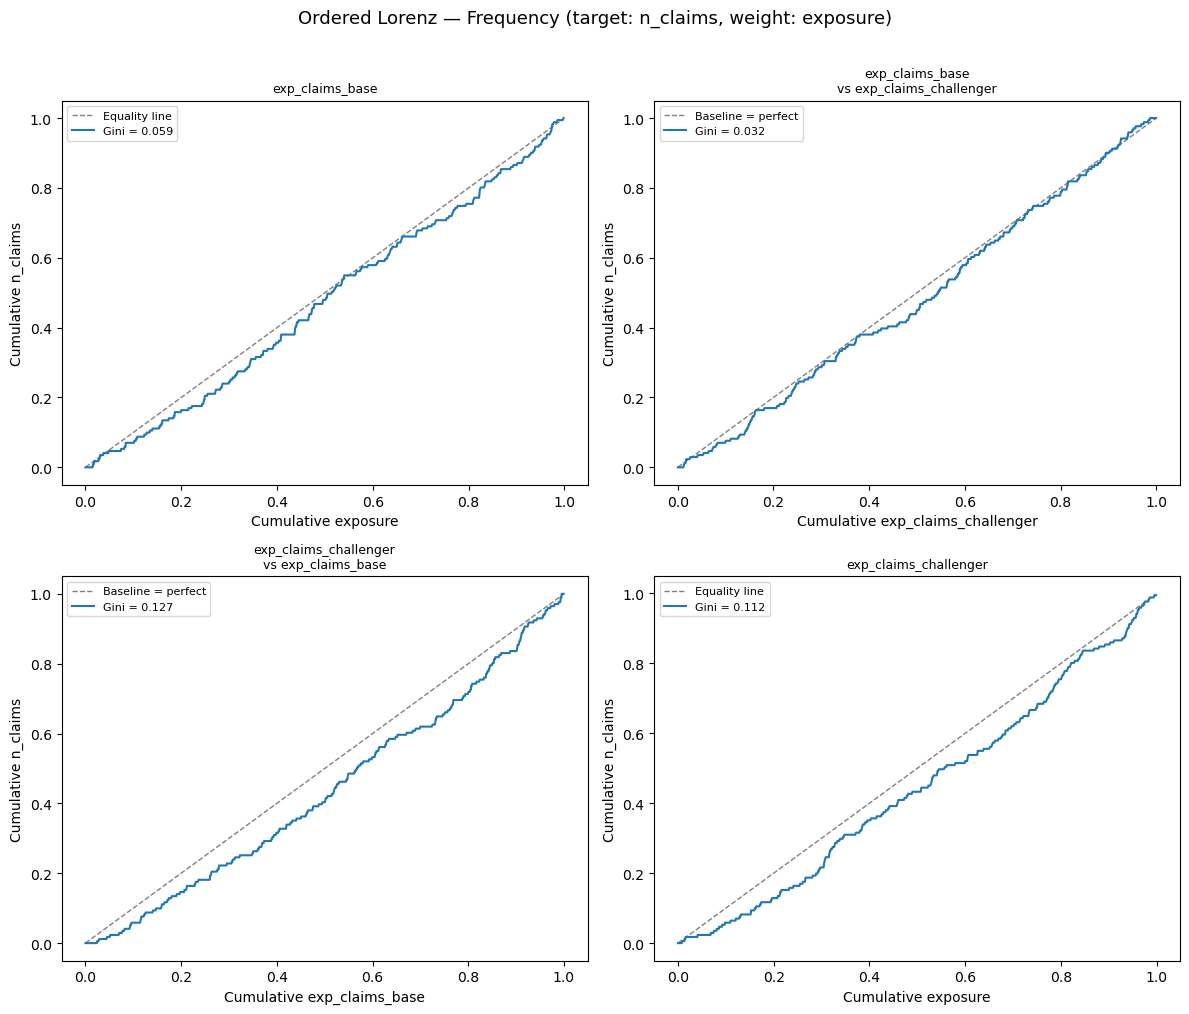

Frequency Gini coefficients (normalised):
  Base (GLM)                         : 0.0586
  Challenger (XGBoost + frozen)      : 0.1123


In [7]:
n = len(freq_models)
fig, axs = plt.subplots(n, n, figsize=(n * 6, n * 5))
fig.suptitle("Ordered Lorenz — Frequency (target: n_claims, weight: exposure)",
             fontsize=13, y=1.01)

gini_freq = {}
for i in range(n):
    for j in range(n):
        ax = axs[i, j] if n > 1 else axs
        if i == j:
            g = ordered_lorenz(
                df, target="n_claims",
                ranking=freq_models[i],
                weight="exposure",
                ascending=True, ax=ax,
            )
            gini_freq[freq_labels[i]] = g
        else:
            g = ordered_lorenz_comparison(
                df, target="n_claims",
                ranking_new=freq_models[i],
                ranking_base=freq_models[j],
                weight="exposure",
                ascending=True, ax=ax,
            )

plt.tight_layout()
plt.show()

print("Frequency Gini coefficients (normalised):")
for name, g in gini_freq.items():
    print(f"  {name:35s}: {g:.4f}")

## 04. Severity Lorenz Curves

**Target**: `claim_amount` (actual total loss — 0 for non-claimants)  
**Ranking**: `sev_glm` or `sev_xgb` (predicted cost per claim)  
**Weight**: `n_claims`  

Note: severity is evaluated on claimants only (non-claimants have
`claim_amount = 0` and `n_claims = 0`, so they do not contribute to the curve).

Claimants in test set: 168


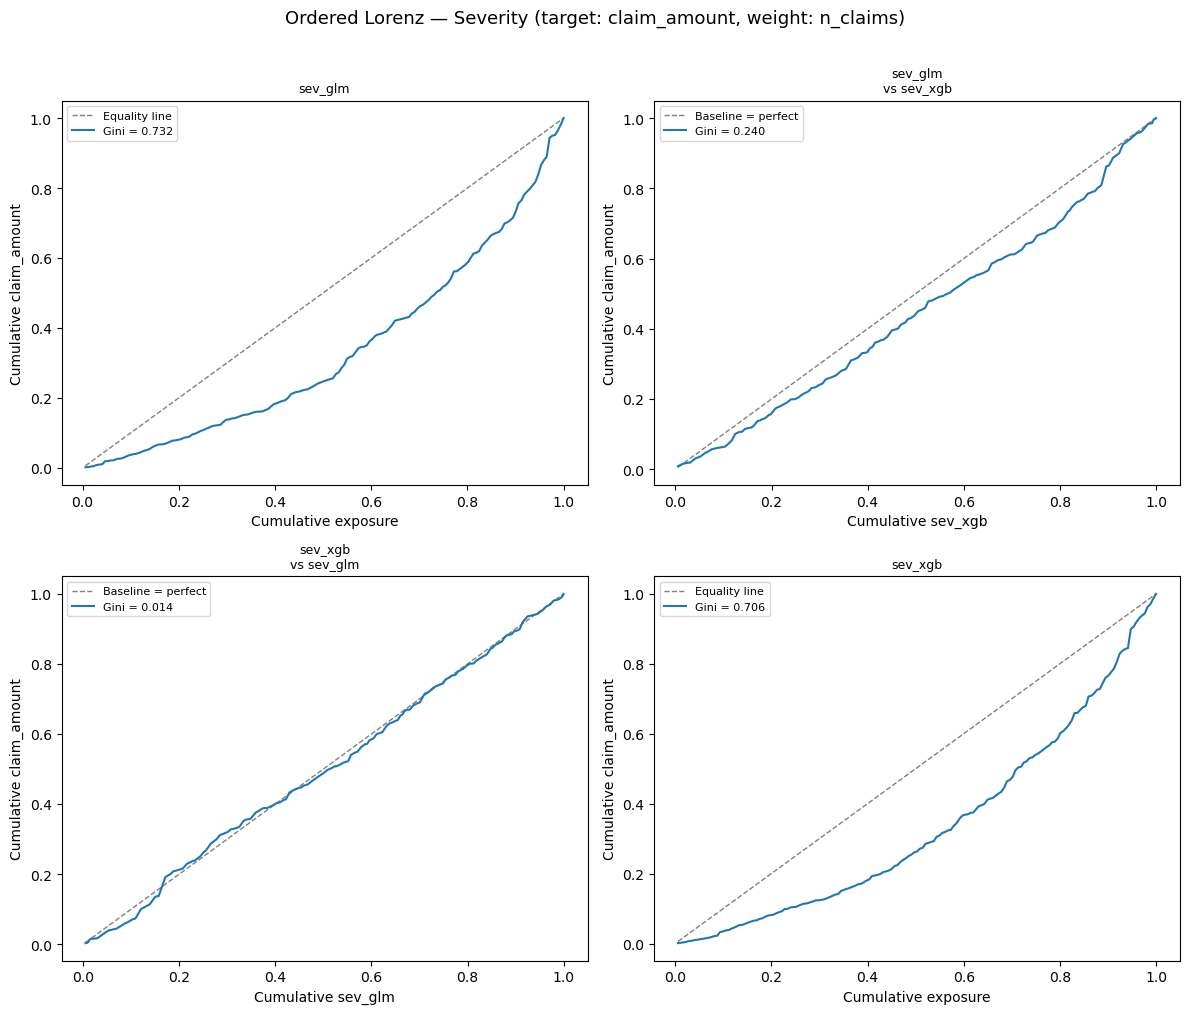

Severity Gini coefficients (normalised):
  GLM (Gamma)                        : 0.7323
  XGBoost (reg:gamma)                : 0.7059


In [8]:
df_claimants = df[df["n_claims"] > 0].copy()
print(f"Claimants in test set: {len(df_claimants):,}")

sev_models = ["sev_glm", "sev_xgb"]
sev_labels = ["GLM (Gamma)", "XGBoost (reg:gamma)"]

n = len(sev_models)
fig, axs = plt.subplots(n, n, figsize=(n * 6, n * 5))
fig.suptitle("Ordered Lorenz — Severity (target: claim_amount, weight: n_claims)",
             fontsize=13, y=1.01)

gini_sev = {}
for i in range(n):
    for j in range(n):
        ax = axs[i, j] if n > 1 else axs
        if i == j:
            g = ordered_lorenz(
                df_claimants, target="claim_amount",
                ranking=sev_models[i],
                weight="n_claims",
                ascending=True, ax=ax,
            )
            gini_sev[sev_labels[i]] = g
        else:
            g = ordered_lorenz_comparison(
                df_claimants, target="claim_amount",
                ranking_new=sev_models[i],
                ranking_base=sev_models[j],
                weight="n_claims",
                ascending=True, ax=ax,
            )

plt.tight_layout()
plt.show()

print("Severity Gini coefficients (normalised):")
for name, g in gini_sev.items():
    print(f"  {name:35s}: {g:.4f}")

## 05. Pure Premium Lorenz Curves

**Pure premium** = frequency × severity = expected annual loss per policy.

**Target**: `claim_amount` (actual total loss)  
**Ranking**: `pp_base` or `pp_challenger` (predicted annual cost)  
**Weight**: `exposure`

This is the ultimate measure of model quality for pricing: how well does
the combined model rank policies from lowest to highest risk?

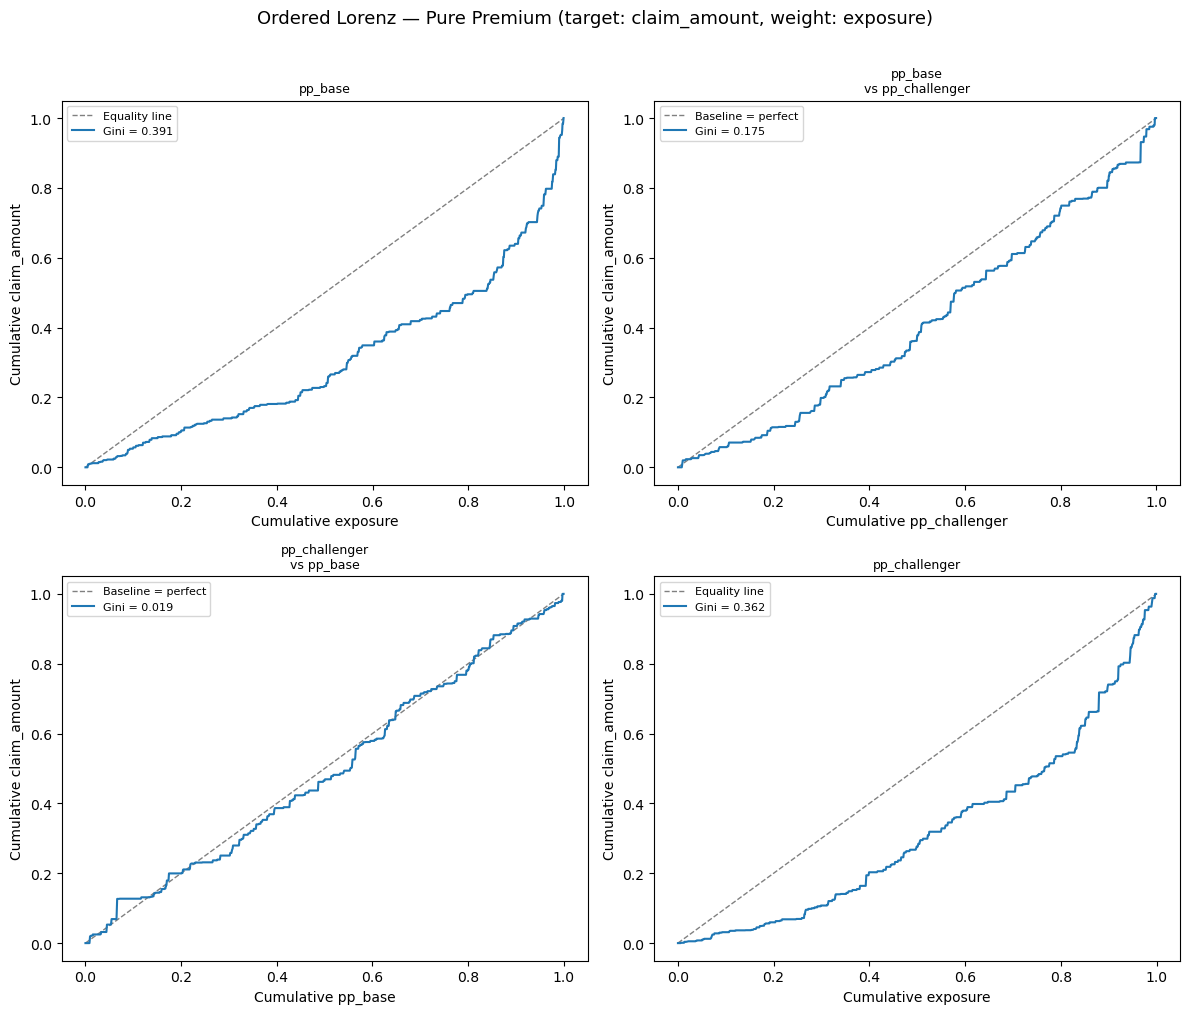

Pure Premium Gini coefficients (normalised):
  Base PP (GLM freq × GLM sev)                      : 0.3908
  Challenger PP (XGBoost freq × XGBoost sev)        : 0.3624


In [9]:
pp_models = ["pp_base", "pp_challenger"]
pp_labels = ["Base PP (GLM freq × GLM sev)", "Challenger PP (XGBoost freq × XGBoost sev)"]

n = len(pp_models)
fig, axs = plt.subplots(n, n, figsize=(n * 6, n * 5))
fig.suptitle("Ordered Lorenz — Pure Premium (target: claim_amount, weight: exposure)",
             fontsize=13, y=1.01)

gini_pp = {}
for i in range(n):
    for j in range(n):
        ax = axs[i, j] if n > 1 else axs
        if i == j:
            g = ordered_lorenz(
                df, target="claim_amount",
                ranking=pp_models[i],
                weight="exposure",
                ascending=True, ax=ax,
            )
            gini_pp[pp_labels[i]] = g
        else:
            g = ordered_lorenz_comparison(
                df, target="claim_amount",
                ranking_new=pp_models[i],
                ranking_base=pp_models[j],
                weight="exposure",
                ascending=True, ax=ax,
            )

plt.tight_layout()
plt.show()

print("Pure Premium Gini coefficients (normalised):")
for name, g in gini_pp.items():
    print(f"  {name:50s}: {g:.4f}")

## 06. Summary

In [10]:
summary = pd.DataFrame([
    {"Component": "Frequency", "Model": name, "Gini": g}
    for name, g in gini_freq.items()
] + [
    {"Component": "Severity",  "Model": name, "Gini": g}
    for name, g in gini_sev.items()
] + [
    {"Component": "Pure Premium", "Model": name, "Gini": g}
    for name, g in gini_pp.items()
])

summary["Gini"] = summary["Gini"].round(4)
print(summary.to_string(index=False))

   Component                                      Model   Gini
   Frequency                                 Base (GLM) 0.0586
   Frequency              Challenger (XGBoost + frozen) 0.1123
    Severity                                GLM (Gamma) 0.7323
    Severity                        XGBoost (reg:gamma) 0.7059
Pure Premium               Base PP (GLM freq × GLM sev) 0.3908
Pure Premium Challenger PP (XGBoost freq × XGBoost sev) 0.3624


## Interpretation Guide

| Gini range | Interpretation |
|------------|----------------|
| 0.00 – 0.10 | Very low discrimination — model barely separates risk |
| 0.10 – 0.25 | Moderate — model provides useful risk segmentation |
| 0.25 – 0.40 | Good — strong commercial value in pricing |
| > 0.40 | Excellent — very high discrimination power |

**Comparison Lorenz (off-diagonal cells)**:
- A **positive Gini** means the row model is better than the column model
- A **zero Gini** means they rank identically
- A **negative Gini** means the column model is actually better

The challenger (XGBoost + frozen base) is expected to outperform the base
GLM by capturing non-linear effects and cross-feature interactions that
the log-linear GLM cannot model.